# Critic Value Landscape Visualization

This notebook visualizes the value function learned by the critic.

**Features:**
- Input positions in absolute coordinates (relative to goal at 0,0)
- Automatically handles local frame transformations
- Plots heatmap of critic values for different agent/box positions
- Compare different scenarios or different critic checkpoints

**Setup:**
1. Train a model and save critic checkpoint
2. Update `checkpoint_path` below
3. Run all cells
4. Modify positions in the "Run Visualization" cell

## 1. Setup and Imports

In [19]:
import sys
sys.path.insert(0, '/home/gvlab/new-universal-MAPush/HARL')
sys.path.insert(0, '/home/gvlab/new-universal-MAPush')

# CRITICAL: Import isaacgym BEFORE torch
import isaacgym

# Now safe to import torch and other libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrow
from matplotlib.collections import PatchCollection

print("✅ Imports successful")

✅ Imports successful


## 2. Load Critic Model

**Easy Configuration:** Just change TWO variables at the top of the next cell:
1. `checkpoint_path` - Path to your critic checkpoint
2. `CRITIC_TYPE` - Which critic type ("critic15", "critic16", "critic9", or "critic7")

The notebook will automatically configure everything else (dimensions, state construction, etc.)!

In [20]:
from harl.models.value_function_models.v_net import VNet
from gym import spaces

# ============================================
# CONFIGURATION - CHANGE THESE TWO VARIABLES
# ============================================
checkpoint_path = "/home/gvlab/new-universal-MAPush/results/mapush/go1push_mid/happo/critic16/seed-00007-2026-01-09-13-22-30/checkpoints/199M/critic_agent.pt"
# SELECT YOUR CRITIC TYPE (change this to match your checkpoint!)
CRITIC_TYPE = "critic16"  # Options: "critic15", "critic16", "critic9", "critic7"

# ============================================
# CRITIC CONFIGURATIONS (DO NOT MODIFY)
# ============================================
CRITIC_CONFIGS = {
    "critic15": {
        "name": "CRITIC15 (Concatenated Ego-Centric)",
        "dims": 16,
        "description": "[agent0_obs(8), agent1_obs(8)]",
        "state_type": "concat_ego",
    },
    "critic16": {
        "name": "CRITIC16 (Goal-Centered)",
        "dims": 9,
        "description": "[box_rel(3), agent0_rel(3), agent1_rel(3)] relative to GOAL",
        "state_type": "goal_centered",
    },
    "critic9": {
        "name": "CRITIC9 (Box-Centered)",
        "dims": 9,
        "description": "[target_rel(2), agent0_rel(3), agent1_rel(3), box_yaw(1)] relative to BOX",
        "state_type": "box_centered",
    },
    "critic7": {
        "name": "CRITIC7 (Absolute World Frame)",
        "dims": 11,
        "description": "[box(3), target(2), agent0(3), agent1(3)] absolute coordinates",
        "state_type": "absolute",
    },
}

if CRITIC_TYPE not in CRITIC_CONFIGS:
    raise ValueError(f"Invalid CRITIC_TYPE '{CRITIC_TYPE}'. Choose from: {list(CRITIC_CONFIGS.keys())}")

config = CRITIC_CONFIGS[CRITIC_TYPE]

# ============================================
# Load Critic Model
# ============================================
device = "cpu"  # Use CPU for visualization (faster for single queries)

# Create VNet with ALL required args (matching HARL training config)
args = {
    'hidden_sizes': [256, 256, 128],
    'initialization_method': 'orthogonal_',
    'use_naive_recurrent_policy': False,
    'use_recurrent_policy': False,
    'recurrent_n': 1,
    'use_feature_normalization': True,
    'activation_func': 'relu',
    'use_conv1d': False,
    'stacked_frames': 1,
    'layer_N': 1,
    'use_maxpool2d': False,
}

# Set input dimensions based on critic type
cent_obs_space = spaces.Box(low=-float('inf'), high=float('inf'), shape=(config["dims"],), dtype=np.float32)

critic = VNet(args, cent_obs_space, device=device)

try:
    critic.load_state_dict(torch.load(checkpoint_path, map_location=device))
    critic.eval()
    print(f"✅ Loaded critic from: {checkpoint_path}")
    print(f"   Type: {config['name']}")
    print(f"   Model: {config['dims']} → {args['hidden_sizes']} → 1")
    print(f"   Input format: {config['description']}")
    print(f"   State type: {config['state_type']}")
except Exception as e:
    print(f"❌ Failed to load checkpoint: {e}")
    print(f"   Make sure:")
    print(f"   1. Path is correct: {checkpoint_path}")
    print(f"   2. CRITIC_TYPE matches checkpoint (current: {CRITIC_TYPE})")
    print(f"   3. Checkpoint file exists")

✅ Loaded critic from: /home/gvlab/new-universal-MAPush/results/mapush/go1push_mid/happo/critic16/seed-00007-2026-01-09-13-22-30/checkpoints/199M/critic_agent.pt
   Type: CRITIC16 (Goal-Centered)
   Model: 9 → [256, 256, 128] → 1
   Input format: [box_rel(3), agent0_rel(3), agent1_rel(3)] relative to GOAL
   State type: goal_centered


## 3. Coordinate Transformation Functions

These functions convert from absolute world coordinates to local agent frames.

In [21]:
def world_to_local(world_pos, world_yaw, agent_pos, agent_yaw):
    """
    Transform world coordinates to agent's local frame.
    
    Args:
        world_pos: [x, y] in world frame
        world_yaw: yaw in world frame (radians)
        agent_pos: [x, y] agent position in world frame
        agent_yaw: agent yaw in world frame (radians)
    
    Returns:
        local_pos: [x, y] in agent's local frame
        local_yaw: yaw in agent's local frame (radians)
    """
    # Translate to agent origin
    relative_x = world_pos[0] - agent_pos[0]
    relative_y = world_pos[1] - agent_pos[1]
    
    # Rotate by -agent_yaw to align with agent's frame
    cos_yaw = np.cos(-agent_yaw)
    sin_yaw = np.sin(-agent_yaw)
    
    local_x = relative_x * cos_yaw - relative_y * sin_yaw
    local_y = relative_x * sin_yaw + relative_y * cos_yaw
    
    # Transform yaw
    local_yaw = world_yaw - agent_yaw
    
    return np.array([local_x, local_y]), local_yaw


def build_agent_observation(agent_pos, agent_yaw, box_pos, box_yaw, goal_pos, other_agent_pos, other_agent_yaw):
    """
    Build 8-dim observation for one agent in its local frame.
    
    Observation structure (8 dims):
        [target_x, target_y,                      # 2 dims (goal relative to agent)
         box_x, box_y,                            # 2 dims (box relative to agent)
         box_yaw,                                 # 1 dim (box yaw relative to agent)
         other_agent_x, other_agent_y, other_agent_yaw]  # 3 dims
    
    Args:
        All positions/yaws in WORLD frame (absolute coordinates)
    
    Returns:
        obs: torch.Tensor of shape (8,)
    """
    # Transform goal to local frame
    local_goal, _ = world_to_local(goal_pos, 0.0, agent_pos, agent_yaw)
    
    # Transform box to local frame
    local_box, local_box_yaw = world_to_local(box_pos, box_yaw, agent_pos, agent_yaw)
    
    # Transform other agent to local frame
    local_other, local_other_yaw = world_to_local(other_agent_pos, other_agent_yaw, agent_pos, agent_yaw)
    
    # Construct observation
    obs = torch.tensor([
        local_goal[0], local_goal[1],              # target x, y
        local_box[0], local_box[1],                # box x, y
        local_box_yaw,                             # box yaw
        local_other[0], local_other[1], local_other_yaw  # other agent x, y, yaw
    ], dtype=torch.float32)
    
    return obs


def construct_global_state(box_pos, box_yaw, goal_pos, agent0_pos, agent0_yaw, agent1_pos, agent1_yaw):
    """
    Construct global state based on CRITIC_TYPE.
    
    Automatically handles different state representations:
    - critic15: Concatenated ego-centric (16D)
    - critic16: Goal-centered (9D)
    - critic9: Box-centered (9D)
    - critic7: Absolute world frame (11D)
    
    Args:
        All positions: [x, y] arrays in WORLD frame (absolute coordinates relative to goal at 0,0)
        All yaws: float in radians
    
    Returns:
        state: torch.Tensor of shape matching CRITIC_TYPE
    """
    state_type = config["state_type"]
    
    if state_type == "concat_ego":
        # CRITIC15: Concatenated agent observations [agent0_obs(8), agent1_obs(8)]
        agent0_obs = build_agent_observation(
            agent_pos=agent0_pos, agent_yaw=agent0_yaw,
            box_pos=box_pos, box_yaw=box_yaw, goal_pos=goal_pos,
            other_agent_pos=agent1_pos, other_agent_yaw=agent1_yaw
        )
        agent1_obs = build_agent_observation(
            agent_pos=agent1_pos, agent_yaw=agent1_yaw,
            box_pos=box_pos, box_yaw=box_yaw, goal_pos=goal_pos,
            other_agent_pos=agent0_pos, other_agent_yaw=agent0_yaw
        )
        global_state = torch.cat([agent0_obs, agent1_obs], dim=0)
    
    elif state_type == "goal_centered":
        # CRITIC16: Goal-centered [box_rel(3), agent0_rel(3), agent1_rel(3)]
        box_rel = box_pos - goal_pos
        box_yaw_rel = box_yaw  # Goal yaw assumed to be 0
        agent0_rel = agent0_pos - goal_pos
        agent0_yaw_rel = agent0_yaw
        agent1_rel = agent1_pos - goal_pos
        agent1_yaw_rel = agent1_yaw
        
        global_state = torch.tensor([
            box_rel[0], box_rel[1], box_yaw_rel,
            agent0_rel[0], agent0_rel[1], agent0_yaw_rel,
            agent1_rel[0], agent1_rel[1], agent1_yaw_rel
        ], dtype=torch.float32)
    
    elif state_type == "box_centered":
        # CRITIC9: Box-centered [target_rel(2), agent0_rel(3), agent1_rel(3), box_yaw(1)]
        target_rel = goal_pos - box_pos
        agent0_rel = agent0_pos - box_pos
        agent0_yaw_rel = agent0_yaw - box_yaw
        agent1_rel = agent1_pos - box_pos
        agent1_yaw_rel = agent1_yaw - box_yaw
        
        global_state = torch.tensor([
            target_rel[0], target_rel[1],
            agent0_rel[0], agent0_rel[1], agent0_yaw_rel,
            agent1_rel[0], agent1_rel[1], agent1_yaw_rel,
            box_yaw
        ], dtype=torch.float32)
    
    elif state_type == "absolute":
        # CRITIC7: Absolute [box(3), target(2), agent0(3), agent1(3)]
        global_state = torch.tensor([
            box_pos[0], box_pos[1], box_yaw,
            goal_pos[0], goal_pos[1],
            agent0_pos[0], agent0_pos[1], agent0_yaw,
            agent1_pos[0], agent1_pos[1], agent1_yaw
        ], dtype=torch.float32)
    
    else:
        raise ValueError(f"Unknown state_type: {state_type}")
    
    return global_state

print("✅ Coordinate transformation functions defined")
print(f"   Configured for: {config['name']} ({config['dims']} dims)")

✅ Coordinate transformation functions defined
   Configured for: CRITIC16 (Goal-Centered) (9 dims)


## 4. Visualization Functions

In [22]:
def query_critic_value(critic, box_pos, box_yaw, goal_pos, agent0_pos, agent0_yaw, agent1_pos, agent1_yaw):
    """
    Query critic for a single state configuration.
    
    Args:
        All in absolute world coordinates
    
    Returns:
        value: float, critic's value estimate V(s)
    """
    state = construct_global_state(
        box_pos=box_pos,
        box_yaw=box_yaw,
        goal_pos=goal_pos,
        agent0_pos=agent0_pos,
        agent0_yaw=agent0_yaw,
        agent1_pos=agent1_pos,
        agent1_yaw=agent1_yaw
    )
    
    # VNet.forward() expects (cent_obs, rnn_states, masks)
    # We don't use RNN, so dummy values
    rnn_states = torch.zeros(1, 1, dtype=torch.float32)
    masks = torch.ones(1, 1, dtype=torch.float32)
    
    with torch.no_grad():
        value, _ = critic(state.unsqueeze(0), rnn_states, masks)
        value = value.item()
    
    return value


def plot_value_heatmap(
    critic,
    box_pos, box_yaw,
    goal_pos,
    agent1_pos, agent1_yaw,
    agent0_yaw=0.0,
    x_range=None,
    y_range=None,
    resolution=100,
    title="Critic Value Landscape"
):
    """
    Plot heatmap of critic values by sweeping agent 0's position.
    
    Args:
        critic: Trained critic model
        box_pos: [x, y] box position (FIXED)
        box_yaw: box yaw (FIXED)
        goal_pos: [x, y] goal position (usually [0, 0])
        agent1_pos: [x, y] agent 1 position (FIXED)
        agent1_yaw: agent 1 yaw (FIXED)
        agent0_yaw: agent 0 yaw (FIXED, default 0)
        x_range: [min, max] for x sweep (default: auto)
        y_range: [min, max] for y sweep (default: auto)
        resolution: grid resolution (default: 100x100)
        title: plot title
    """
    # Auto-determine ranges if not specified
    if x_range is None:
        x_range = [goal_pos[0] - 2, box_pos[0] + 2]
    if y_range is None:
        y_range = [goal_pos[1] - 3, goal_pos[1] + 3]
    
    # Create grid
    x_grid = np.linspace(x_range[0], x_range[1], resolution)
    y_grid = np.linspace(y_range[0], y_range[1], resolution)
    
    value_grid = np.zeros((len(y_grid), len(x_grid)))
    
    print(f"Computing {resolution}x{resolution} = {resolution**2} critic values...")
    
    # Sweep agent 0 position
    for i, y in enumerate(y_grid):
        for j, x in enumerate(x_grid):
            agent0_pos = np.array([x, y])
            
            value = query_critic_value(
                critic=critic,
                box_pos=box_pos,
                box_yaw=box_yaw,
                goal_pos=goal_pos,
                agent0_pos=agent0_pos,
                agent0_yaw=agent0_yaw,
                agent1_pos=agent1_pos,
                agent1_yaw=agent1_yaw
            )
            
            value_grid[i, j] = value
        
        # Progress indicator
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(y_grid)} rows completed")
    
    print("✅ Computation complete. Plotting...")
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Heatmap
    im = ax.imshow(
        value_grid,
        extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
        origin='lower',
        cmap='RdYlGn',
        aspect='auto',
        alpha=0.8
    )
    cbar = plt.colorbar(im, ax=ax, label='Critic Value V(s)', shrink=0.8)
    
    # Overlay objects
    # Goal (green star)
    ax.scatter(*goal_pos, c='green', s=500, marker='*', 
               label='Goal', edgecolors='black', linewidths=3, zorder=10)
    
    # Box (blue square)
    box_size = 1.2  # 1.2m × 1.2m box
    box_rect = Rectangle(
        (box_pos[0] - box_size/2, box_pos[1] - box_size/2),
        box_size, box_size,
        angle=np.degrees(box_yaw),
        facecolor='blue',
        edgecolor='black',
        linewidth=2,
        alpha=0.7,
        label='Box',
        zorder=9
    )
    ax.add_patch(box_rect)
    
    # Agent 1 (orange circle, FIXED)
    ax.scatter(*agent1_pos, c='orange', s=300, marker='o',
               label='Agent 1 (fixed)', edgecolors='black', linewidths=2, zorder=11)
    # Agent 1 heading arrow
    arrow_len = 0.5
    ax.arrow(
        agent1_pos[0], agent1_pos[1],
        arrow_len * np.cos(agent1_yaw), arrow_len * np.sin(agent1_yaw),
        head_width=0.2, head_length=0.15, fc='orange', ec='black', linewidth=1.5, zorder=11
    )
    
    # Annotations
    ax.set_xlabel('X Position (m)', fontsize=12)
    ax.set_ylabel('Y Position (m)', fontsize=12)
    ax.set_title(f'{title}\n(Agent 0 position swept across grid)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Value statistics
    stats_text = f"Value Range: [{value_grid.min():.3f}, {value_grid.max():.3f}]\n"
    stats_text += f"Mean: {value_grid.mean():.3f}, Std: {value_grid.std():.3f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return value_grid

print("✅ Visualization functions defined")

✅ Visualization functions defined


## 5. Quick Test: Single State Query

Test the critic on a single configuration to make sure everything works.

In [23]:
# Test configuration: typical successful scenario
test_value = query_critic_value(
    critic=critic,
    box_pos=np.array([4.0, 0.0]),      # Box 4m from goal
    box_yaw=0.0,
    goal_pos=np.array([0.0, 0.0]),     # Goal at origin
    agent0_pos=np.array([5.0, -0.5]),  # Agent 0 behind box (left side)
    agent0_yaw=0.0,
    agent1_pos=np.array([5.0, 0.5]),   # Agent 1 behind box (right side)
    agent1_yaw=0.0
)

print(f"✅ Test query successful!")
print(f"   Scenario: Both agents behind box, ready to push toward goal")
print(f"   Critic value: {test_value:.4f}")
print(f"   Interpretation: {'Good state (positive value)' if test_value > 0 else 'Bad state (negative value)'}")


CRITIC VNet INPUT VERIFICATION
Centralized observation shape: torch.Size([1, 9])
Expected for MAPush 2-agent: [batch_size, 17]
  - Box: [x, y, yaw] = 3 dims
  - Target: [x, y] = 2 dims (NO yaw!)
  - Agent0: [x, y, yaw, vx, vy, vyaw] = 6 dims
  - Agent1: [x, y, yaw, vx, vy, vyaw] = 6 dims
  - Total: 17 dims
✗ ERROR: Expected 17 dims, got 9 dims!

✅ Test query successful!
   Scenario: Both agents behind box, ready to push toward goal
   Critic value: -1.7064
   Interpretation: Bad state (negative value)


## 6. Run Visualization - MODIFY THIS CELL

**Instructions:**
1. Set the fixed positions for box, goal, and agent 1
2. Run the cell to generate a heatmap showing critic values for different agent 0 positions
3. Experiment with different configurations!

**Coordinate System:**
- Goal is at (0, 0) by convention
- Positive X = away from goal (box starts "in front" of goal)
- Y = lateral position
- Yaw in radians (0 = pointing along +X axis)

**Typical Setup:**
- Goal: (0, 0)
- Box: (4, 0) - 4 meters from goal
- Agent 1: (5, 0.6) - behind box, on one side
- Agent 0: SWEPT across grid

Computing 80x80 = 6400 critic values...
  10/80 rows completed
  20/80 rows completed
  30/80 rows completed
  40/80 rows completed
  50/80 rows completed
  60/80 rows completed
  70/80 rows completed
  80/80 rows completed
✅ Computation complete. Plotting...


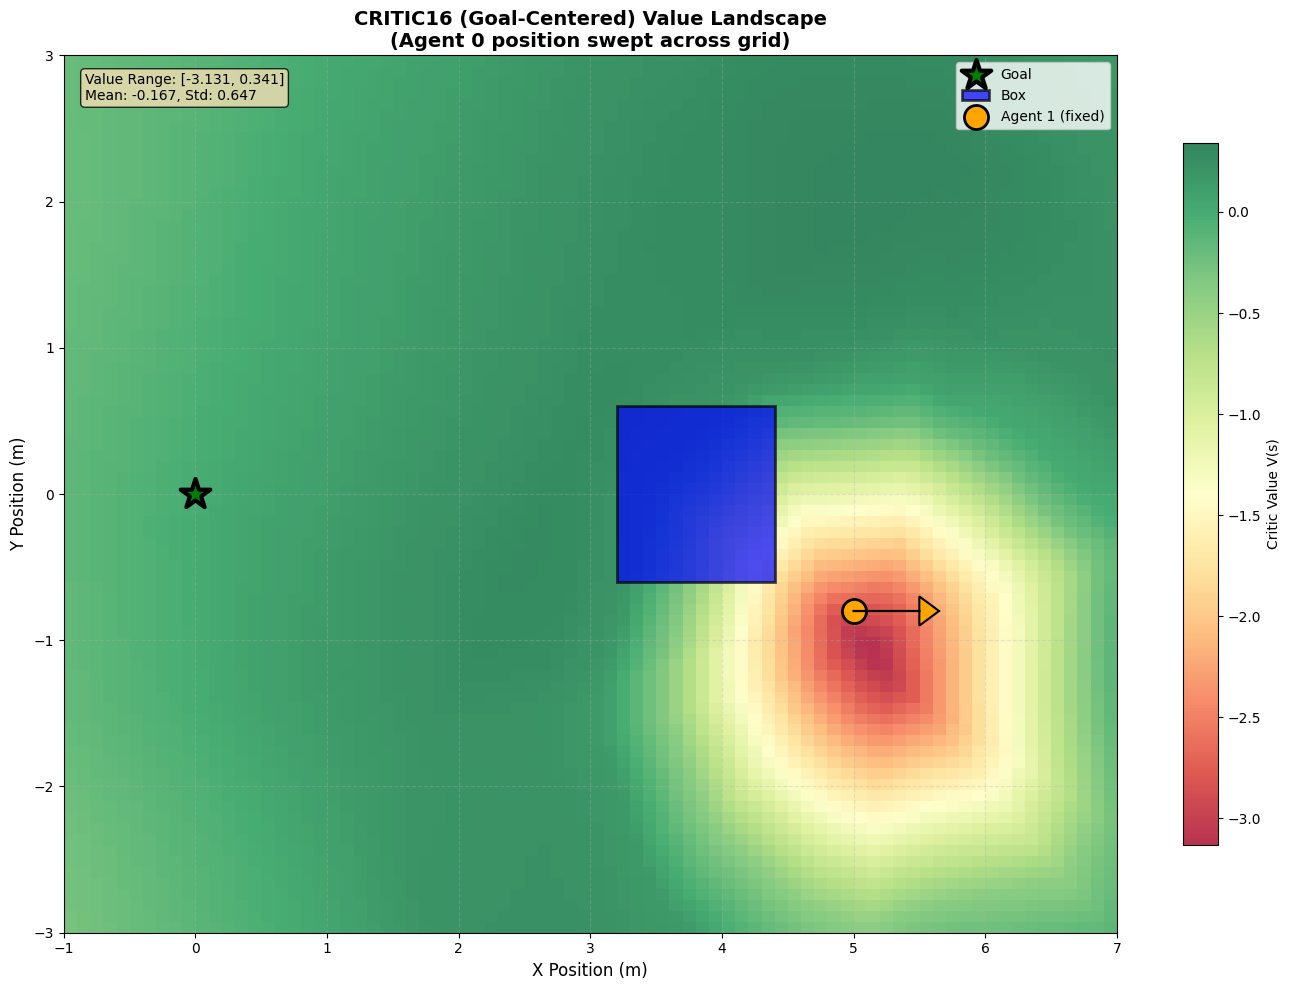

In [24]:
# ============================================
# MODIFY THESE POSITIONS (absolute coordinates)
# ============================================

# Goal position (usually at origin)
goal_pos = np.array([0.0, 0.0])

# Box position and orientation
box_pos = np.array([3.8, 0.0])  # x m from goal
box_yaw = 0.0                    # radians (0 = aligned with X axis)

# Agent 1 position and orientation (FIXED)
agent1_pos = np.array([5.0, -0.8])  # Behind box, on right side
agent1_yaw = 0.0                    # radians

# Agent 0 yaw (position is SWEPT across grid)
agent0_yaw = 0.0  # radians

# Grid ranges (auto if None)
x_range = [-1, 7]   # From goal to past box
y_range = [-3, 3]   # ±3m lateral

# Resolution (higher = slower but more detailed)
resolution = 80  # 80x80 = 6,400 queries (takes ~30 sec on CPU)

# ============================================
# RUN VISUALIZATION
# ============================================

value_grid = plot_value_heatmap(
    critic=critic,
    box_pos=box_pos,
    box_yaw=box_yaw,
    goal_pos=goal_pos,
    agent1_pos=agent1_pos,
    agent1_yaw=agent1_yaw,
    agent0_yaw=agent0_yaw,
    x_range=x_range,
    y_range=y_range,
    resolution=resolution,
    title=f"{config['name']} Value Landscape"  # Auto-title from config
)

## 7. Compare Different Scenarios

Run multiple scenarios side-by-side to understand what the critic learned.


Scenario: Agent 1 Behind Box (Correct)
Computing 60x60 = 3600 critic values...
  10/60 rows completed
  20/60 rows completed
  30/60 rows completed
  40/60 rows completed
  50/60 rows completed
  60/60 rows completed
✅ Computation complete. Plotting...


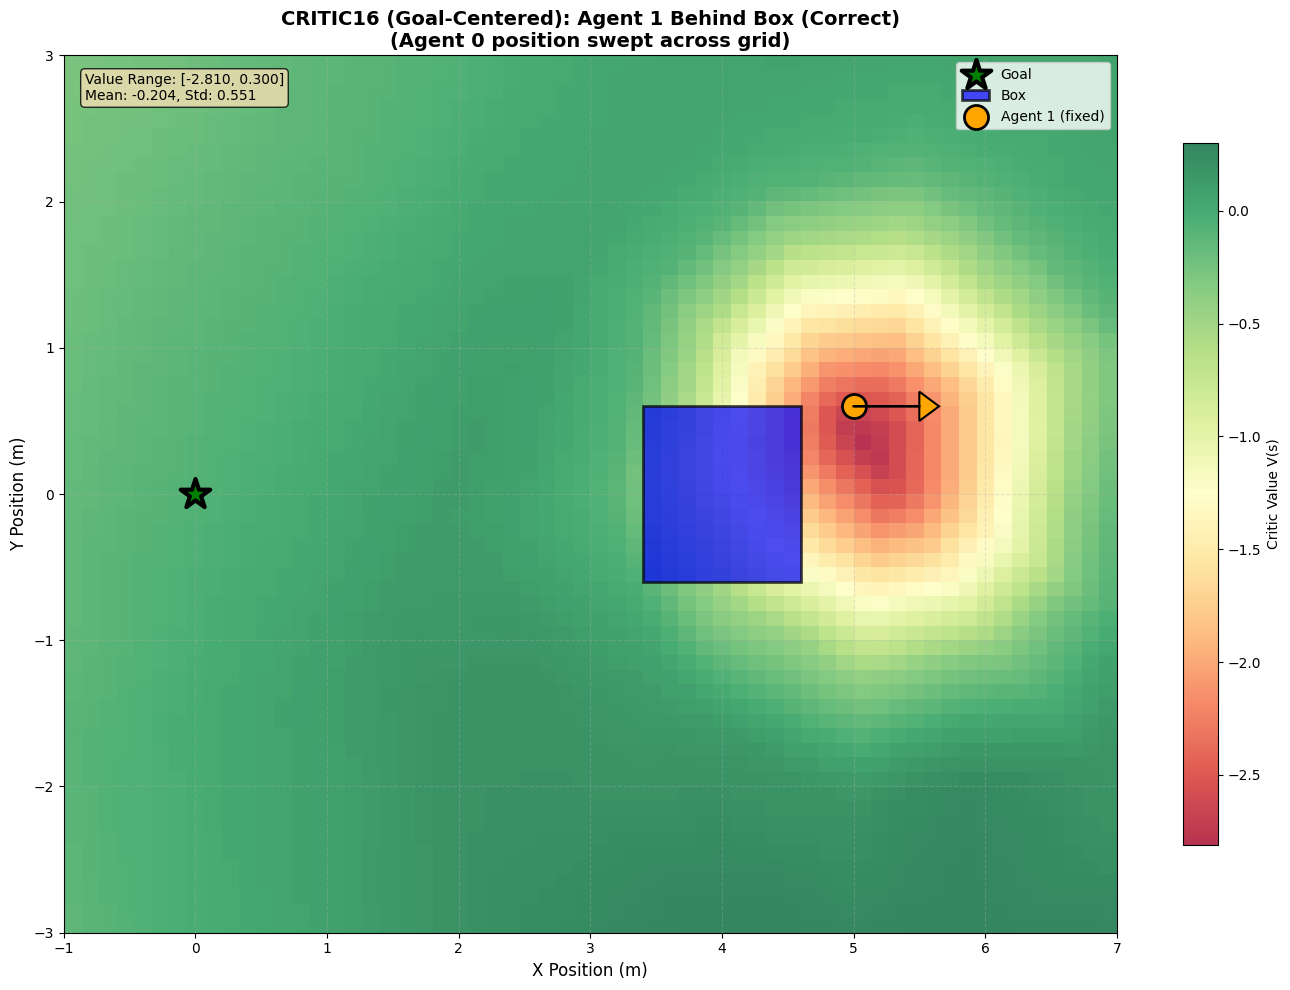


Scenario: Agent 1 In Front (Blocking)
Computing 60x60 = 3600 critic values...
  10/60 rows completed
  20/60 rows completed
  30/60 rows completed
  40/60 rows completed
  50/60 rows completed
  60/60 rows completed
✅ Computation complete. Plotting...


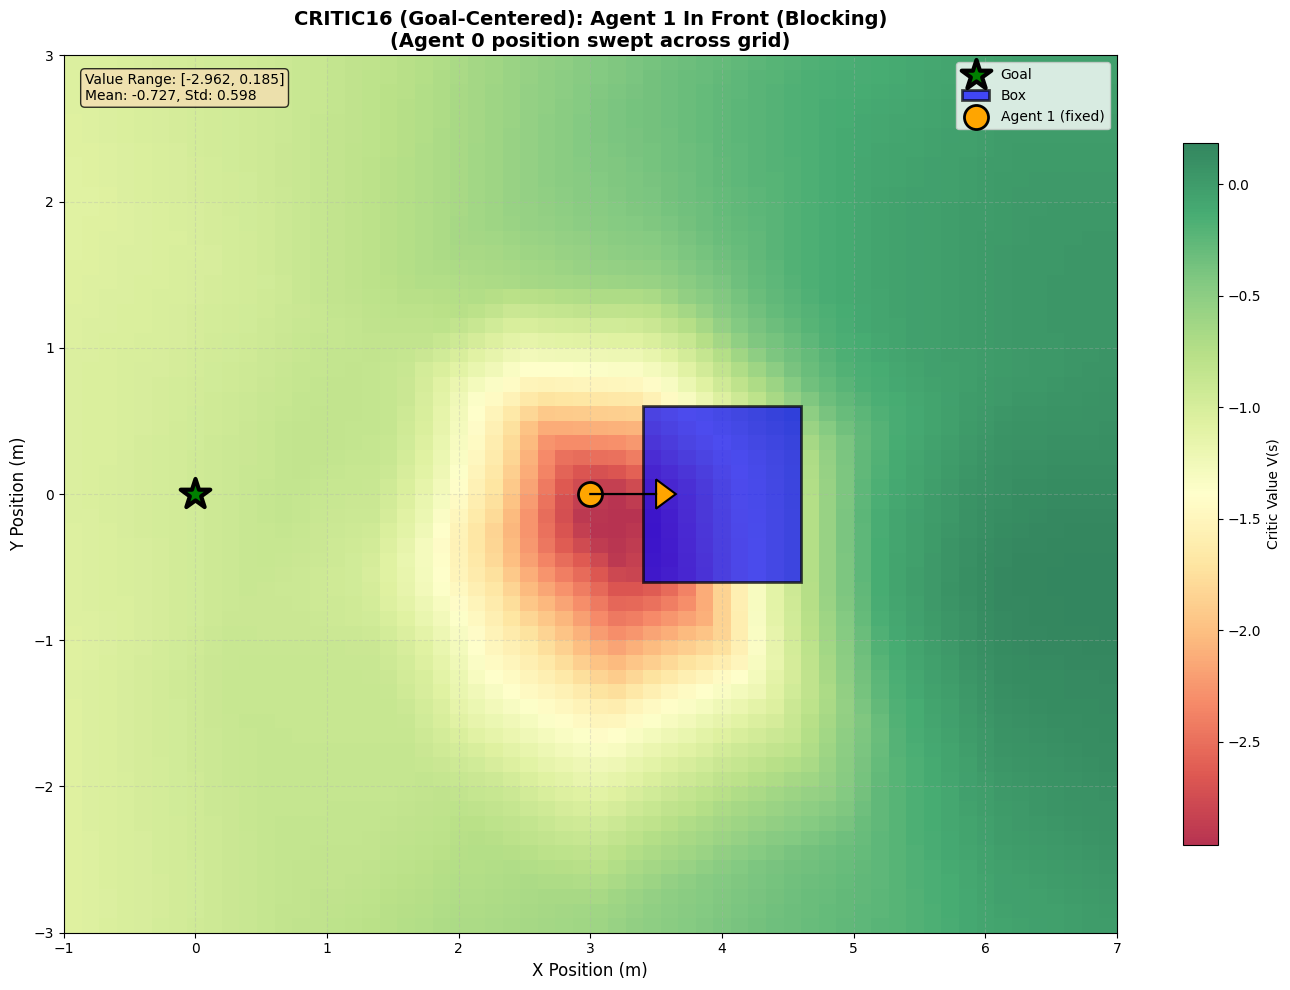


Scenario: Agent 1 To The Side
Computing 60x60 = 3600 critic values...
  10/60 rows completed
  20/60 rows completed
  30/60 rows completed
  40/60 rows completed
  50/60 rows completed
  60/60 rows completed
✅ Computation complete. Plotting...


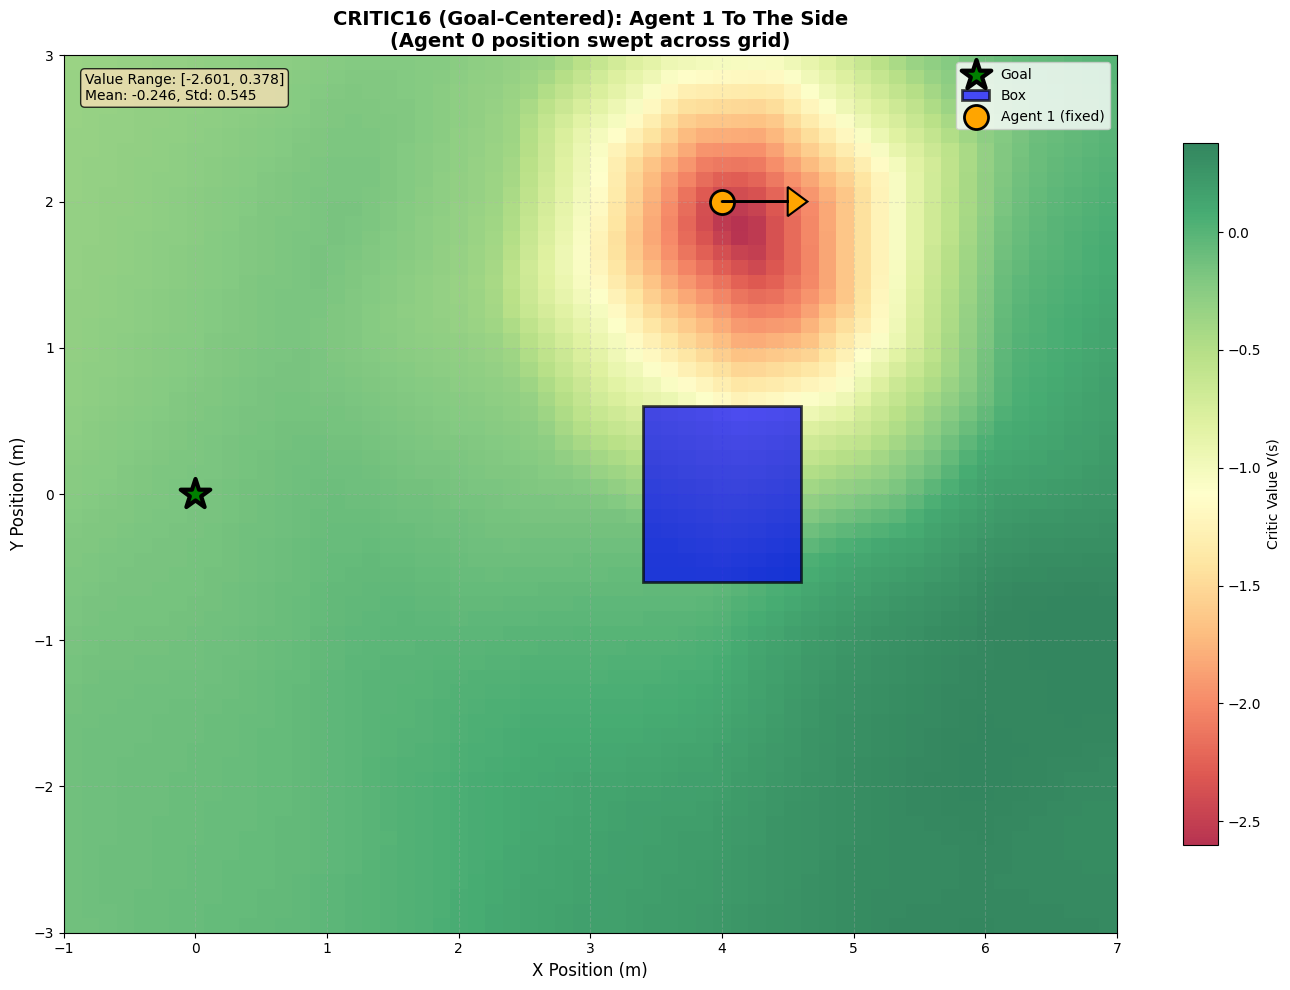


Scenario: Agent 1 Far Behind Box
Computing 60x60 = 3600 critic values...
  10/60 rows completed
  20/60 rows completed
  30/60 rows completed
  40/60 rows completed
  50/60 rows completed
  60/60 rows completed
✅ Computation complete. Plotting...


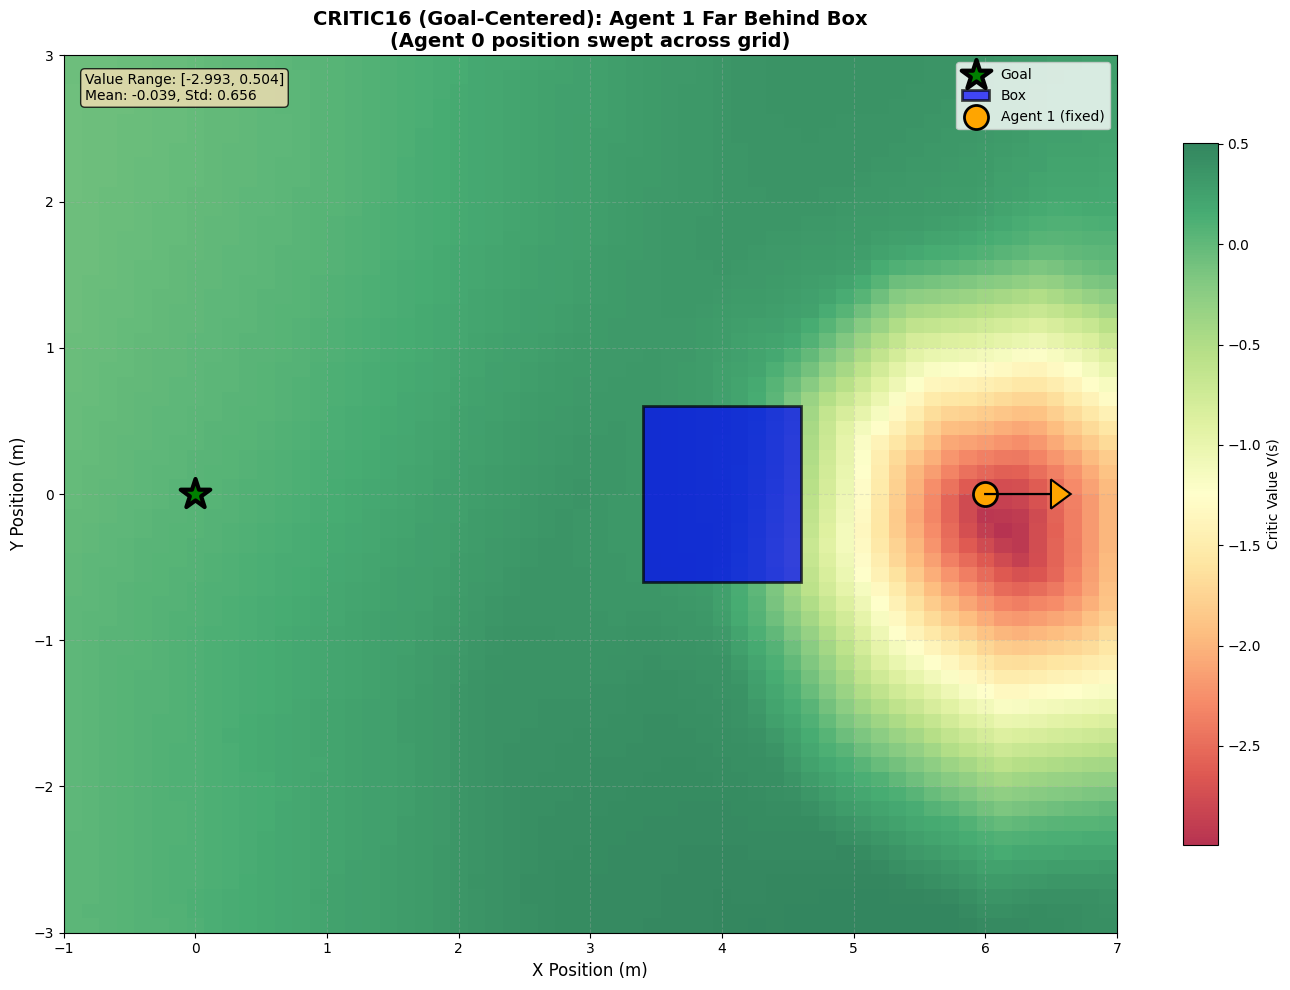

In [25]:
# Scenario comparison: Different agent 1 positions

scenarios = [
    {
        'name': 'Agent 1 Behind Box (Correct)',
        'agent1_pos': np.array([5.0, 0.6]),
        'agent1_yaw': 0.0
    },
    {
        'name': 'Agent 1 In Front (Blocking)',
        'agent1_pos': np.array([3.0, 0.0]),
        'agent1_yaw': 0.0
    },
    {
        'name': 'Agent 1 To The Side',
        'agent1_pos': np.array([4.0, 2.0]),
        'agent1_yaw': 0.0
    },
    {
        'name': 'Agent 1 Far Behind Box',
        'agent1_pos': np.array([6.0, 0.0]),
        'agent1_yaw': 0.0
    },
]

# Plot all scenarios
for scenario in scenarios:
    print(f"\n{'='*60}")
    print(f"Scenario: {scenario['name']}")
    print(f"{'='*60}")
    
    plot_value_heatmap(
        critic=critic,
        box_pos=np.array([4.0, 0.0]),
        box_yaw=0.0,
        goal_pos=np.array([0.0, 0.0]),
        agent1_pos=scenario['agent1_pos'],
        agent1_yaw=scenario['agent1_yaw'],
        agent0_yaw=0.0,
        x_range=[-1, 7],
        y_range=[-3, 3],
        resolution=60,  # Lower resolution for faster comparison
        title=f"{config['name']}: {scenario['name']}"  # Auto-title from config
    )

## 8. Compare Two Critics (Optional)

Load two different checkpoints and visualize the difference in value estimates.

In [26]:
# Load second critic for comparison
checkpoint_path_2 = "results/mapush/go1push_mid/happo/critic14/seed-00007-2026-01-06-22-31-46/checkpoints/100M/critic_agent.pt"

# Create second VNet with same architecture
args2 = {
    'hidden_sizes': [256, 256, 128, 64],  # FIXED: Actual architecture
    'initialization_method': 'orthogonal_',
    'use_naive_recurrent_policy': False,
    'use_recurrent_policy': False,
    'recurrent_n': 1,
    'use_feature_normalization': True,
    'activation_func': 'relu',
    'use_conv1d': False,
    'stacked_frames': 1,
    'layer_N': 1,
    'use_maxpool2d': False,
}
cent_obs_space2 = spaces.Box(low=-float('inf'), high=float('inf'), shape=(16,), dtype=np.float32)
critic2 = VNet(args2, cent_obs_space2, device=device)

try:
    critic2.load_state_dict(torch.load(checkpoint_path_2, map_location=device))
    critic2.eval()
    print(f"✅ Loaded second critic from: {checkpoint_path_2}")
    
    # Compute value grids for both
    print("\nComputing CRITIC1 values...")
    grid1 = plot_value_heatmap(
        critic=critic,
        box_pos=np.array([4.0, 0.0]),
        box_yaw=0.0,
        goal_pos=np.array([0.0, 0.0]),
        agent1_pos=np.array([5.0, 0.6]),
        agent1_yaw=0.0,
        agent0_yaw=0.0,
        x_range=[-1, 7],
        y_range=[-3, 3],
        resolution=60,
        title="Critic 1"
    )
    
    print("\nComputing CRITIC2 values...")
    grid2 = plot_value_heatmap(
        critic=critic2,
        box_pos=np.array([4.0, 0.0]),
        box_yaw=0.0,
        goal_pos=np.array([0.0, 0.0]),
        agent1_pos=np.array([5.0, 0.6]),
        agent1_yaw=0.0,
        agent0_yaw=0.0,
        x_range=[-1, 7],
        y_range=[-3, 3],
        resolution=60,
        title="Critic 2"
    )
    
    # Plot difference
    print("\nPlotting difference...")
    diff = grid1 - grid2
    
    fig, ax = plt.subplots(figsize=(14, 10))
    max_abs = max(abs(diff.min()), abs(diff.max()))
    
    im = ax.imshow(
        diff,
        extent=[-1, 7, -3, 3],
        origin='lower',
        cmap='RdBu',
        vmin=-max_abs,
        vmax=max_abs,
        aspect='auto'
    )
    plt.colorbar(im, ax=ax, label='Value Difference (Critic1 - Critic2)')
    
    ax.set_xlabel('X Position (m)', fontsize=12)
    ax.set_ylabel('Y Position (m)', fontsize=12)
    ax.set_title('Value Difference: Critic1 - Critic2\n(Red = Critic1 higher, Blue = Critic2 higher)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Failed to load second critic: {e}")
    print(f"   Skipping comparison.")

❌ Failed to load second critic: [Errno 2] No such file or directory: 'results/mapush/go1push_mid/happo/critic14/seed-00007-2026-01-06-22-31-46/checkpoints/100M/critic_agent.pt'
   Skipping comparison.


## 9. Analysis Tips

### What to Look For:

**✅ Good Learning:**
- High values (green) behind the box
- Low values (red) in front of box (blocking)
- Values increase as box gets closer to goal
- Symmetric patterns for symmetric scenarios
- Clear value gradient guiding agents to correct positions

**❌ Poor Learning:**
- Uniform values everywhere (critic hasn't learned anything)
- Random/noisy patterns
- High values in clearly bad positions (e.g., blocking the box)
- No clear gradient toward correct positioning

### Experiments to Try:

1. **Box distance from goal:** Does value increase as box gets closer?
2. **Agent positioning:** Where does critic think agents should be?
3. **Cooperation:** Does value increase when both agents are positioned correctly?
4. **OCB learning:** Are positions behind box valued higher than in front?
5. **Collision avoidance:** Are positions too close to agent 1 penalized?

### Debugging CRITIC15:

If CRITIC15 has poor performance:
- Check if critic learned meaningful value function
- Compare to CRITIC14 to see what's different
- Look for missing structure (e.g., no directional preference)
- Identify which positions are undervalued/overvalued

## 10. MAPPO Baseline Critic (OpenRL)

Load and visualize the original MAPush MAPPO baseline critic for comparison.

**Key Differences from HAPPO:**
- **MAPPO:** Per-agent critic with 8-dim local observation
- **HAPPO:** Centralized critic with 16-dim global state

**MAPPO Observation (8 dims):**
```
[target_x, target_y,                    # goal relative to agent
 box_x, box_y, box_yaw,                 # box relative to agent
 other_agent_x, other_agent_y, other_agent_yaw]  # other agent relative
```

In [27]:
# ============================================
# Load MAPPO Baseline Critic from OpenRL
# ============================================

# backup_MAPush path is needed because the checkpoint contains pickled OpenRL classes
# Python needs to find openrl.modules.ppo_module.PPOModule to unpickle the checkpoint
import sys
if '/home/gvlab/backup_MAPush' not in sys.path:
    sys.path.insert(0, '/home/gvlab/backup_MAPush')

mappo_checkpoint_path = "/home/gvlab/new-universal-MAPush/results/models/baseline_mappo/mid/checkpoints/rl_model_130000000_steps/module.pt"

try:
    # Load the full OpenRL module (contains both actor and critic)
    # weights_only=False required because checkpoint contains full module objects
    mappo_module = torch.load(mappo_checkpoint_path, map_location='cpu', weights_only=False)
    
    # Extract the critic network
    mappo_critic = mappo_module.models['critic']
    
    # CRITICAL: Override device settings to force CPU
    # OpenRL models have CUDA device baked in from training
    mappo_critic.tpdv = {'device': torch.device('cpu'), 'dtype': torch.float32}
    mappo_critic.to('cpu')
    mappo_critic.eval()
    
    print(f"✅ Loaded MAPPO baseline critic from: {mappo_checkpoint_path}")
    print(f"   Model type: {type(mappo_critic).__name__}")
    print(f"   Input: 8 dims (per-agent local observation)")
    print(f"   Architecture: 8 → [256, 256, 256, 256] → 1")
    print(f"   Checkpoint: 130M steps (best baseline)")
    
except Exception as e:
    print(f"❌ Failed to load MAPPO critic: {e}")
    print(f"   Make sure you ran the imports cell (cell-2) first!")
    print(f"   Also ensure backup_MAPush exists at /home/gvlab/backup_MAPush")

✅ Loaded MAPPO baseline critic from: /home/gvlab/new-universal-MAPush/results/models/baseline_mappo/mid/checkpoints/rl_model_130000000_steps/module.pt
   Model type: ValueNetwork
   Input: 8 dims (per-agent local observation)
   Architecture: 8 → [256, 256, 256, 256] → 1
   Checkpoint: 130M steps (best baseline)


In [28]:
# ============================================
# MAPPO Critic Query Function
# ============================================

def query_mappo_critic_value(mappo_critic, box_pos, box_yaw, goal_pos, agent_pos, agent_yaw, other_agent_pos, other_agent_yaw):
    """
    Query MAPPO critic for a single agent's state.
    
    MAPPO uses per-agent critic with 8-dim local observation (not global state).
    
    Args:
        mappo_critic: OpenRL ValueNetwork
        box_pos, box_yaw: box position/orientation in world frame
        goal_pos: goal position in world frame
        agent_pos, agent_yaw: THIS agent's position/orientation
        other_agent_pos, other_agent_yaw: OTHER agent's position/orientation
    
    Returns:
        value: float, critic's value estimate V(o_agent)
    """
    # Build 8-dim observation for this agent (uses existing function!)
    obs = build_agent_observation(
        agent_pos=agent_pos,
        agent_yaw=agent_yaw,
        box_pos=box_pos,
        box_yaw=box_yaw,
        goal_pos=goal_pos,
        other_agent_pos=other_agent_pos,
        other_agent_yaw=other_agent_yaw
    )
    
    # OpenRL critic expects (obs, rnn_states, masks)
    # No RNN used, so dummy values
    rnn_states = torch.zeros(1, 1, 256, dtype=torch.float32)
    masks = torch.ones(1, 1, dtype=torch.float32)
    
    with torch.no_grad():
        # Forward returns (value, rnn_states)
        value, _ = mappo_critic(obs.unsqueeze(0), rnn_states, masks)
        value = value.squeeze().item()
    
    return value


def plot_mappo_value_heatmap(
    mappo_critic,
    box_pos, box_yaw,
    goal_pos,
    agent1_pos, agent1_yaw,
    agent0_yaw=0.0,
    x_range=None,
    y_range=None,
    resolution=80,
    title="MAPPO Baseline Critic Value Landscape"
):
    """
    Plot heatmap of MAPPO critic values by sweeping agent 0's position.
    
    Note: MAPPO has per-agent critic, so we query V(o_agent0) for each position.
    """
    # Auto-determine ranges if not specified
    if x_range is None:
        x_range = [goal_pos[0] - 2, box_pos[0] + 2]
    if y_range is None:
        y_range = [goal_pos[1] - 3, goal_pos[1] + 3]
    
    # Create grid
    x_grid = np.linspace(x_range[0], x_range[1], resolution)
    y_grid = np.linspace(y_range[0], y_range[1], resolution)
    
    value_grid = np.zeros((len(y_grid), len(x_grid)))
    
    print(f"Computing {resolution}x{resolution} = {resolution**2} MAPPO critic values...")
    
    # Sweep agent 0 position
    for i, y in enumerate(y_grid):
        for j, x in enumerate(x_grid):
            agent0_pos = np.array([x, y])
            
            value = query_mappo_critic_value(
                mappo_critic=mappo_critic,
                box_pos=box_pos,
                box_yaw=box_yaw,
                goal_pos=goal_pos,
                agent_pos=agent0_pos,
                agent_yaw=agent0_yaw,
                other_agent_pos=agent1_pos,
                other_agent_yaw=agent1_yaw
            )
            
            value_grid[i, j] = value
        
        # Progress indicator
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(y_grid)} rows completed")
    
    print("✅ Computation complete. Plotting...")
    
    # Plot heatmap (same style as HAPPO for comparison)
    fig, ax = plt.subplots(figsize=(14, 10))
    
    im = ax.imshow(
        value_grid,
        extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
        origin='lower',
        cmap='RdYlGn',
        aspect='auto',
        alpha=0.8
    )
    cbar = plt.colorbar(im, ax=ax, label='MAPPO Critic Value V(o_agent)', shrink=0.8)
    
    # Overlay objects
    ax.scatter(*goal_pos, c='green', s=500, marker='*', 
               label='Goal', edgecolors='black', linewidths=3, zorder=10)
    
    box_size = 1.2
    box_rect = Rectangle(
        (box_pos[0] - box_size/2, box_pos[1] - box_size/2),
        box_size, box_size,
        angle=np.degrees(box_yaw),
        facecolor='blue',
        edgecolor='black',
        linewidth=2,
        alpha=0.7,
        label='Box',
        zorder=9
    )
    ax.add_patch(box_rect)
    
    ax.scatter(*agent1_pos, c='orange', s=300, marker='o',
               label='Agent 1 (fixed)', edgecolors='black', linewidths=2, zorder=11)
    arrow_len = 0.5
    ax.arrow(
        agent1_pos[0], agent1_pos[1],
        arrow_len * np.cos(agent1_yaw), arrow_len * np.sin(agent1_yaw),
        head_width=0.2, head_length=0.15, fc='orange', ec='black', linewidth=1.5, zorder=11
    )
    
    ax.set_xlabel('X Position (m)', fontsize=12)
    ax.set_ylabel('Y Position (m)', fontsize=12)
    ax.set_title(f'{title}\n(Agent 0 position swept across grid)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    stats_text = f"Value Range: [{value_grid.min():.3f}, {value_grid.max():.3f}]\n"
    stats_text += f"Mean: {value_grid.mean():.3f}, Std: {value_grid.std():.3f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return value_grid

print("✅ MAPPO visualization functions defined")

✅ MAPPO visualization functions defined


## 11. Visualize MAPPO Baseline Critic

Run the same scenarios as HAPPO to compare value landscapes.

MAPPO BASELINE (130M steps) - Best original model
Computing 80x80 = 6400 MAPPO critic values...
  10/80 rows completed
  20/80 rows completed
  30/80 rows completed
  40/80 rows completed
  50/80 rows completed
  60/80 rows completed
  70/80 rows completed
  80/80 rows completed
✅ Computation complete. Plotting...


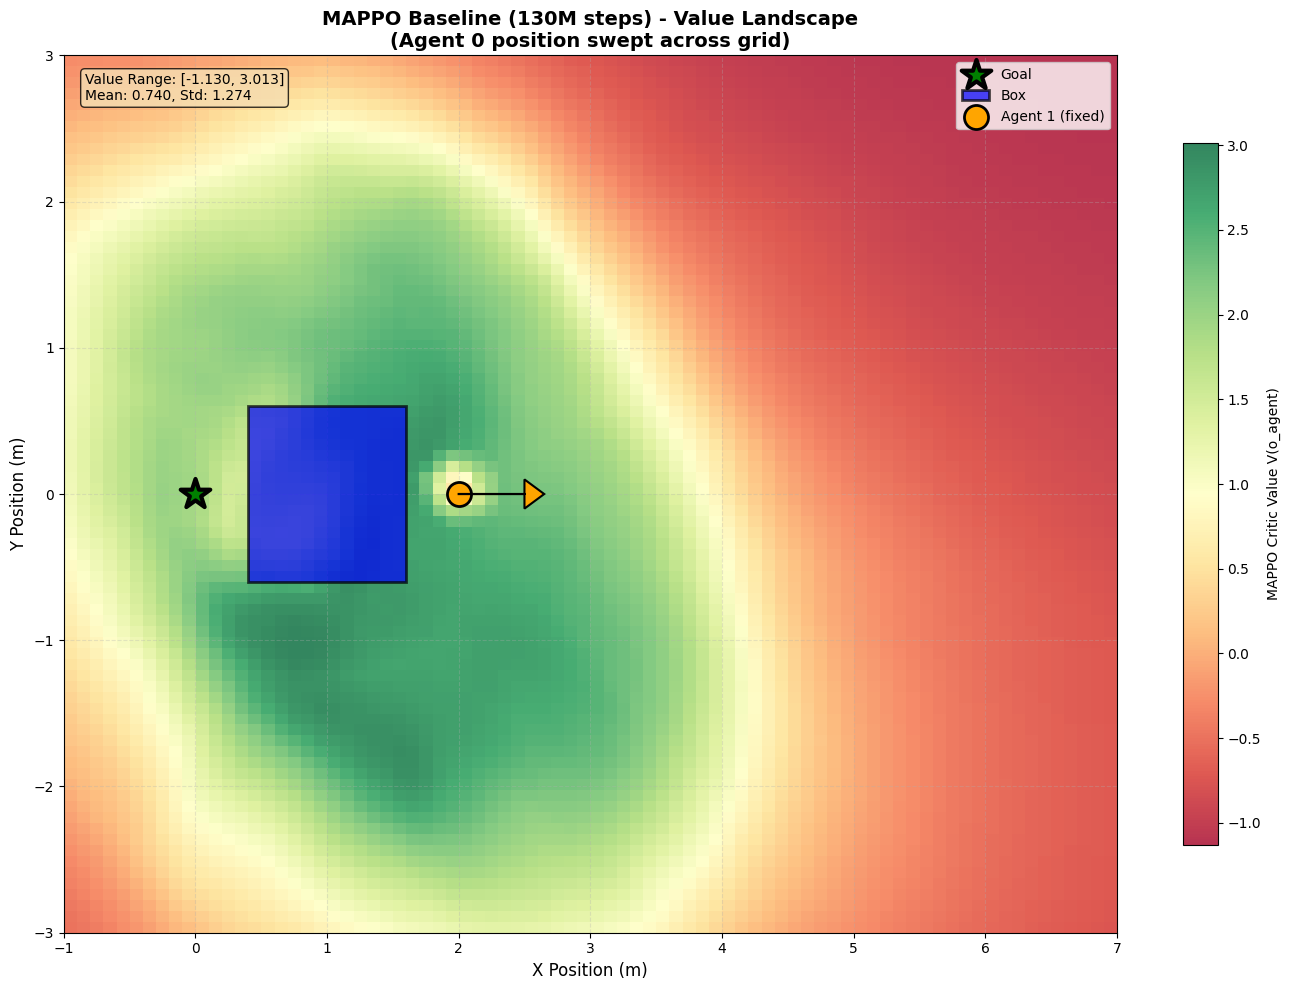

In [29]:
# ============================================
# MAPPO Baseline Visualization
# ============================================

# Use same configuration as HAPPO visualizations for comparison
goal_pos = np.array([0.0, 0.0])
box_pos = np.array([1.0, 0.0])
box_yaw = 0.0

# Agent 1 behind box (good position)
agent1_pos = np.array([2.0, 0])
agent1_yaw = 0.0

# Agent 0 yaw
agent0_yaw = 0.0

# Grid ranges
x_range = [-1, 7]
y_range = [-3, 3]
resolution = 80

# Run MAPPO visualization
print("=" * 60)
print("MAPPO BASELINE (130M steps) - Best original model")
print("=" * 60)

mappo_value_grid = plot_mappo_value_heatmap(
    mappo_critic=mappo_critic,
    box_pos=box_pos,
    box_yaw=box_yaw,
    goal_pos=goal_pos,
    agent1_pos=agent1_pos,
    agent1_yaw=agent1_yaw,
    agent0_yaw=agent0_yaw,
    x_range=x_range,
    y_range=y_range,
    resolution=resolution,
    title="MAPPO Baseline (130M steps) - Value Landscape"
)

## 12. Side-by-Side Comparison: HAPPO vs MAPPO

Compare the value landscapes from both critics to understand the differences in learned value functions.

Computing HAPPO values...
  HAPPO: 20/80 rows
  HAPPO: 40/80 rows
  HAPPO: 60/80 rows
  HAPPO: 80/80 rows
Computing MAPPO (Baseline) values...
  MAPPO: 20/80 rows
  MAPPO: 40/80 rows
  MAPPO: 60/80 rows
  MAPPO: 80/80 rows


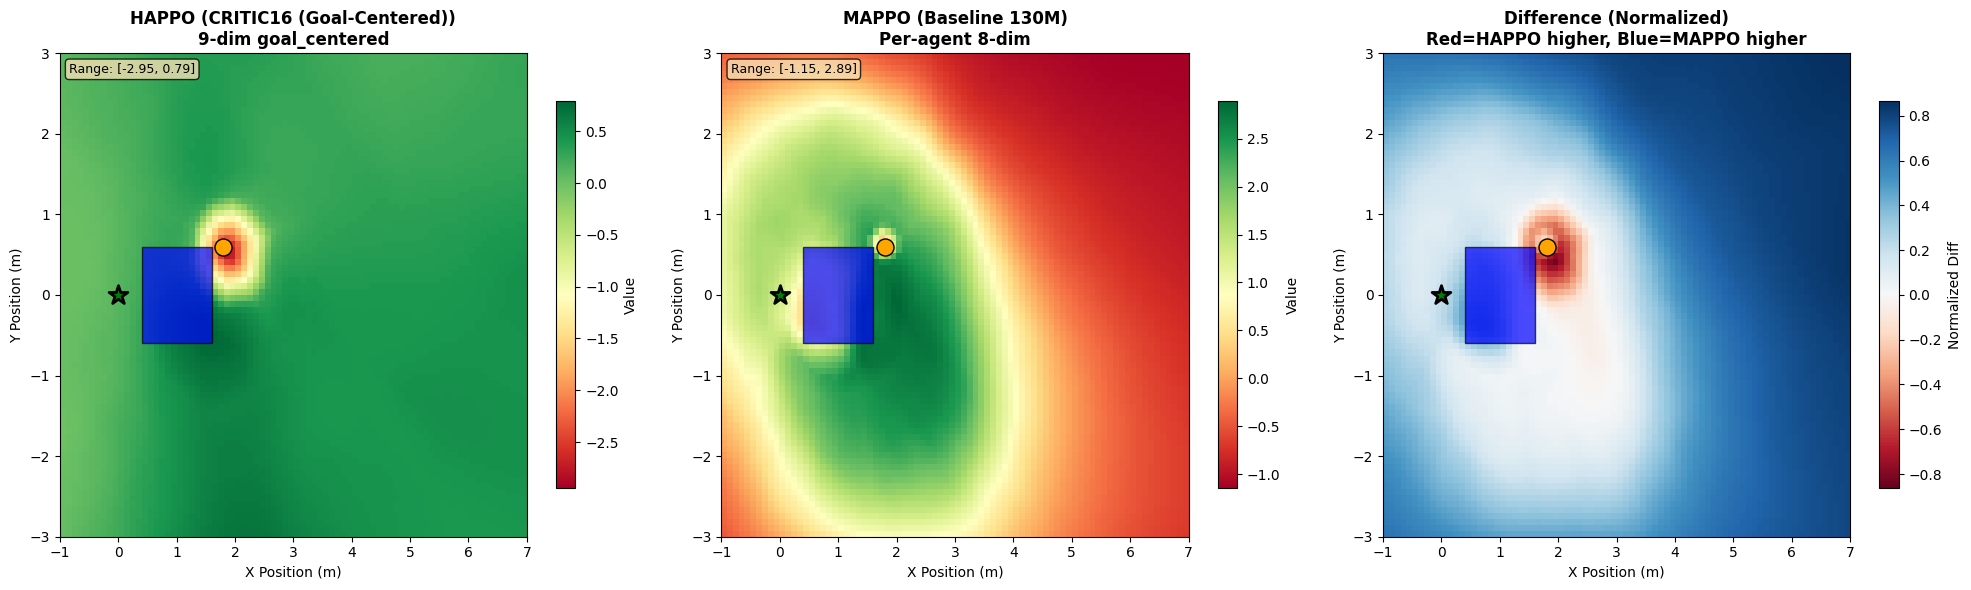


✅ Comparison complete! Saved to happo_vs_mappo_comparison.png


In [31]:
# ============================================
# Side-by-Side Comparison: HAPPO vs MAPPO
# ============================================

# Compute both value grids with same configuration
goal_pos = np.array([0.0, 0.0])
box_pos = np.array([1.0, 0.0])
box_yaw = 0.0
agent1_pos = np.array([1.8, 0.6])
agent1_yaw = 0.0
agent0_yaw = 0.0
x_range = [-1, 7]
y_range = [-3, 3]
resolution = 80  # Lower for faster comparison

print("Computing HAPPO values...")
happo_grid = np.zeros((resolution, resolution))
x_grid = np.linspace(x_range[0], x_range[1], resolution)
y_grid = np.linspace(y_range[0], y_range[1], resolution)

for i, y in enumerate(y_grid):
    for j, x in enumerate(x_grid):
        agent0_pos = np.array([x, y])
        happo_grid[i, j] = query_critic_value(
            critic=critic, box_pos=box_pos, box_yaw=box_yaw, goal_pos=goal_pos,
            agent0_pos=agent0_pos, agent0_yaw=agent0_yaw,
            agent1_pos=agent1_pos, agent1_yaw=agent1_yaw
        )
    if (i + 1) % 20 == 0:
        print(f"  HAPPO: {i+1}/{resolution} rows")

print("Computing MAPPO (Baseline) values...")
mappo_grid = np.zeros((resolution, resolution))

for i, y in enumerate(y_grid):
    for j, x in enumerate(x_grid):
        agent0_pos = np.array([x, y])
        mappo_grid[i, j] = query_mappo_critic_value(
            mappo_critic=mappo_critic, box_pos=box_pos, box_yaw=box_yaw, goal_pos=goal_pos,
            agent_pos=agent0_pos, agent_yaw=agent0_yaw,
            other_agent_pos=agent1_pos, other_agent_yaw=agent1_yaw
        )
    if (i + 1) % 20 == 0:
        print(f"  MAPPO: {i+1}/{resolution} rows")

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# HAPPO - use config for title and dimensions
im1 = axes[0].imshow(happo_grid, extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
                      origin='lower', cmap='RdYlGn', aspect='auto')
axes[0].set_title(f"HAPPO ({config['name']})\n{config['dims']}-dim {config['state_type']}", 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('X Position (m)')
axes[0].set_ylabel('Y Position (m)')
plt.colorbar(im1, ax=axes[0], label='Value', shrink=0.8)

# Add box and goal to HAPPO plot
axes[0].scatter(*goal_pos, c='green', s=200, marker='*', edgecolors='black', linewidths=2, zorder=10)
box_rect1 = Rectangle((box_pos[0] - 0.6, box_pos[1] - 0.6), 1.2, 1.2,
                        facecolor='blue', edgecolor='black', alpha=0.7, zorder=9)
axes[0].add_patch(box_rect1)
axes[0].scatter(*agent1_pos, c='orange', s=150, marker='o', edgecolors='black', zorder=11)
stats1 = f"Range: [{happo_grid.min():.2f}, {happo_grid.max():.2f}]"
axes[0].text(0.02, 0.98, stats1, transform=axes[0].transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# MAPPO
im2 = axes[1].imshow(mappo_grid, extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
                      origin='lower', cmap='RdYlGn', aspect='auto')
axes[1].set_title('MAPPO (Baseline 130M)\nPer-agent 8-dim', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X Position (m)')
axes[1].set_ylabel('Y Position (m)')
plt.colorbar(im2, ax=axes[1], label='Value', shrink=0.8)

# Add box and goal to MAPPO plot
axes[1].scatter(*goal_pos, c='green', s=200, marker='*', edgecolors='black', linewidths=2, zorder=10)
box_rect2 = Rectangle((box_pos[0] - 0.6, box_pos[1] - 0.6), 1.2, 1.2,
                        facecolor='blue', edgecolor='black', alpha=0.7, zorder=9)
axes[1].add_patch(box_rect2)
axes[1].scatter(*agent1_pos, c='orange', s=150, marker='o', edgecolors='black', zorder=11)
stats2 = f"Range: [{mappo_grid.min():.2f}, {mappo_grid.max():.2f}]"
axes[1].text(0.02, 0.98, stats2, transform=axes[1].transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Difference (normalized for comparison)
# Normalize both to [0, 1] range before comparing
happo_norm = (happo_grid - happo_grid.min()) / (happo_grid.max() - happo_grid.min() + 1e-8)
mappo_norm = (mappo_grid - mappo_grid.min()) / (mappo_grid.max() - mappo_grid.min() + 1e-8)
diff = happo_norm - mappo_norm

max_diff = max(abs(diff.min()), abs(diff.max()))
im3 = axes[2].imshow(diff, extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
                      origin='lower', cmap='RdBu', vmin=-max_diff, vmax=max_diff, aspect='auto')
axes[2].set_title('Difference (Normalized)\nRed=HAPPO higher, Blue=MAPPO higher', fontsize=12, fontweight='bold')
axes[2].set_xlabel('X Position (m)')
axes[2].set_ylabel('Y Position (m)')
plt.colorbar(im3, ax=axes[2], label='Normalized Diff', shrink=0.8)

# Add box and goal to diff plot
axes[2].scatter(*goal_pos, c='green', s=200, marker='*', edgecolors='black', linewidths=2, zorder=10)
box_rect3 = Rectangle((box_pos[0] - 0.6, box_pos[1] - 0.6), 1.2, 1.2,
                        facecolor='blue', edgecolor='black', alpha=0.7, zorder=9)
axes[2].add_patch(box_rect3)
axes[2].scatter(*agent1_pos, c='orange', s=150, marker='o', edgecolors='black', zorder=11)

plt.tight_layout()
plt.savefig('happo_vs_mappo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Comparison complete! Saved to happo_vs_mappo_comparison.png")